# Sensitivity Analysis: Population & Demographics
This notebook analyses the demographic sensitivity of Nairobi to extreme heat. It processes large raster datasets (like HDX Meta High Resolution Population Density Maps) by:
1. Clipping them to the Nairobi boundary to reduce file size.
2. Resampling them to the common 50m analysis grid.
3. Normalising the indicators (0 = low sensitivity, 1 = high sensitivity).
4. Exporting the final maps for the web dashboard.


In [3]:
import os
import sys
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import gc

sys.path.append('../.')
from src.common_helper import *
from src.sensitivity_helper import *
from src.export_web_maps import *

%load_ext autoreload
%autoreload 2
%matplotlib inline


Failed to read module file 'C:\Users\Surface\anaconda3\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Surface\anaconda3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  

## 1. Setup Grid & Directories

In [4]:
# Create the standard 50m analysis grid for Nairobi
boundary = load_boundary()
grid = create_analysis_grid(boundary, resolution_m=50)

# Define where sensitivity data should be stored
sensitivity_dir = os.path.join(DATA_DIR, 'sensitivity')
os.makedirs(sensitivity_dir, exist_ok=True)
print(f"Please place your downloaded HDX .tif files in: {sensitivity_dir}")


  Grid created: 631 x 982 cells (50 m resolution)
Please place your downloaded HDX .tif files in: c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\data\geospatial\sensitivity


## 2. Run Analysis & Export to Web
Once the rasters are clipped, uncomment the code below to resample them to the analysis grid, normalise them, and export them.


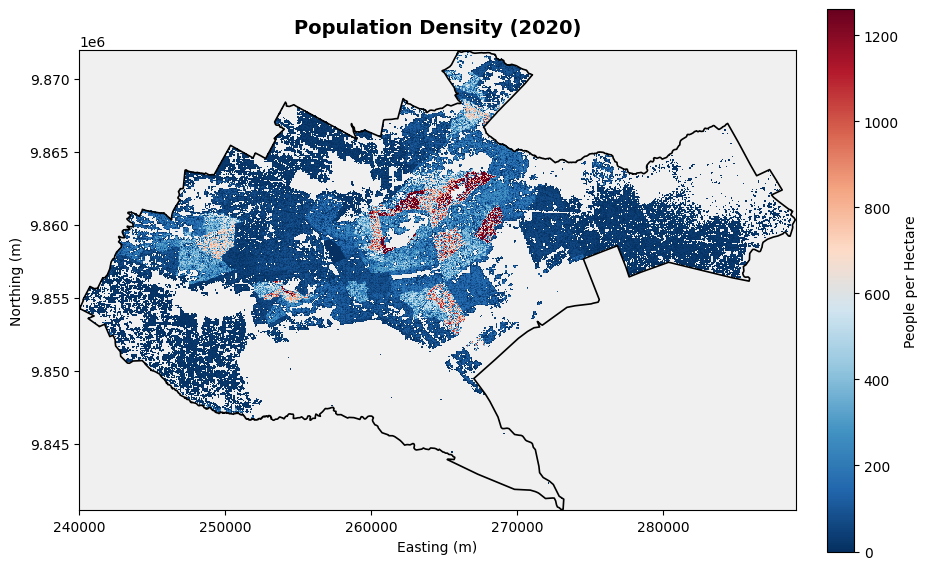

Exported 'sensitivity_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web
Exported raw data for 'sensitivity_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\sensitivity_population_raw.png


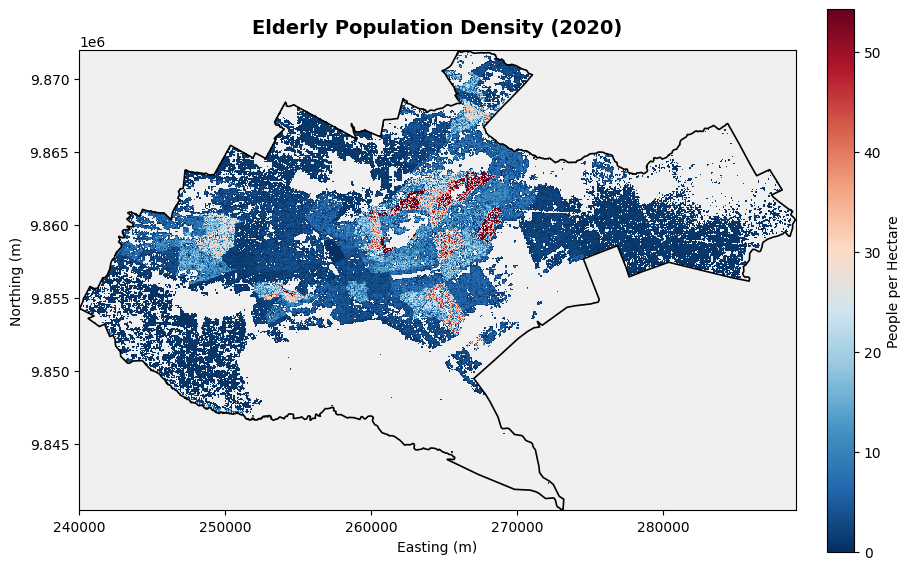

Exported 'sensitivity_elderly_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web
Exported raw data for 'sensitivity_elderly_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\sensitivity_elderly_population_raw.png


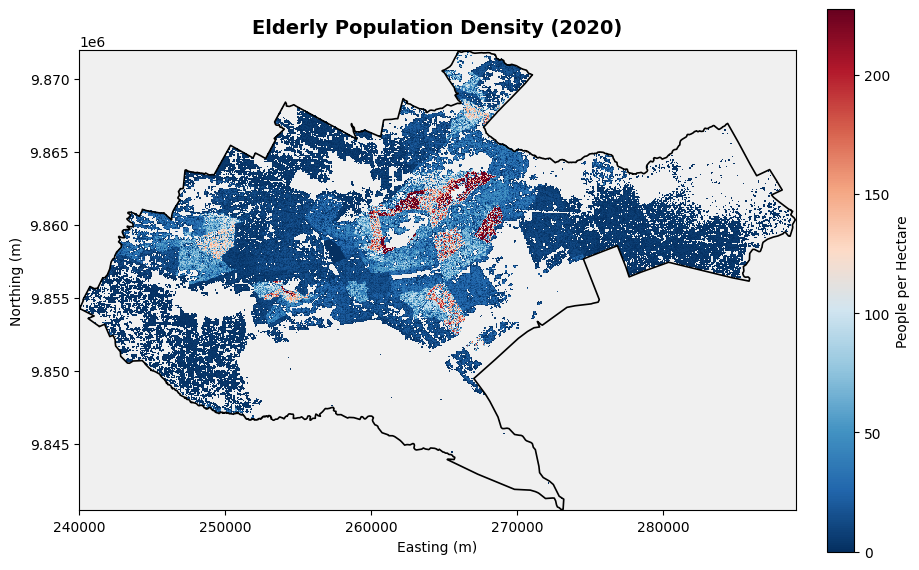

Exported 'sensitivity_children_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web
Exported raw data for 'sensitivity_children_population' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\sensitivity_children_population_raw.png


In [5]:
# 1. Load the raw population counts (people per 50x50m pixel)
pop_count = resample_to_grid(os.path.join(sensitivity_dir, 'nairobi_general_pop_2020.tif'), grid)
if pop_count is not None:
    # 2. Convert to physical units: People per Hectare (1 pixel = 50m*50m = 2500 m^2 = 0.25 ha)
    pixel_area_ha = (grid['resolution'] ** 2) / 10000.0
    pop_density_ha = pop_count / pixel_area_ha
    
    # Calculate a good maximum for the color scale (99th percentile)
    valid_density = pop_density_ha[~np.isnan(pop_density_ha)]
    vmax_val = np.percentile(valid_density, 99) if len(valid_density) > 0 else 1
    
    # 3. Plot using the actual physical values
    ax = plot_layer(
        pop_density_ha, 
        grid, 
        "Population Density (2020)", 
        cmap=COMPOSITE_CMAP.reversed(), 
        cbar_label='People per Hectare',
        vmin=0,
        vmax=vmax_val
    )
    plt.show()
    plt.close(ax.figure)
    
    # 4. Normalize to 0-1 ONLY for the web dashboard composite calculations
    pop_sensitivity = normalize_layer(pop_count)
    export_raster_for_web(pop_sensitivity, grid, 'sensitivity_population', cmap=COMPOSITE_CMAP.reversed())
    export_raw_for_web(pop_sensitivity, grid, 'sensitivity_population')
    
    del pop_count, pop_density_ha, pop_sensitivity, valid_density
    gc.collect()


pop_count = resample_to_grid(os.path.join(sensitivity_dir, 'nairobi_elderly_pop_2020.tif'), grid)
if pop_count is not None:
    pixel_area_ha = (grid['resolution'] ** 2) / 10000.0
    pop_density_ha = pop_count / pixel_area_ha
    
    valid_density = pop_density_ha[~np.isnan(pop_density_ha)]
    vmax_val = np.percentile(valid_density, 99) if len(valid_density) > 0 else 1
    
    ax = plot_layer(
        pop_density_ha, 
        grid, 
        "Elderly Population Density (2020)", 
        cmap=COMPOSITE_CMAP.reversed(), 
        cbar_label='People per Hectare',
        vmin=0,
        vmax=vmax_val
    )
    plt.show()
    plt.close(ax.figure)
    
    pop_sensitivity = normalize_layer(pop_count)
    export_raster_for_web(pop_sensitivity, grid, 'sensitivity_elderly_population', cmap=COMPOSITE_CMAP.reversed())
    export_raw_for_web(pop_sensitivity, grid, 'sensitivity_elderly_population')
    
    del pop_count, pop_density_ha, pop_sensitivity, valid_density
    gc.collect()

pop_count = resample_to_grid(os.path.join(sensitivity_dir, 'nairobi_children_pop_2020.tif'), grid)
if pop_count is not None:
    pixel_area_ha = (grid['resolution'] ** 2) / 10000.0
    pop_density_ha = pop_count / pixel_area_ha
    
    valid_density = pop_density_ha[~np.isnan(pop_density_ha)]
    vmax_val = np.percentile(valid_density, 99) if len(valid_density) > 0 else 1
    
    ax = plot_layer(
        pop_density_ha, 
        grid, 
        "Elderly Population Density (2020)", 
        cmap=COMPOSITE_CMAP.reversed(), 
        cbar_label='People per Hectare',
        vmin=0,
        vmax=vmax_val
    )
    plt.show()
    plt.close(ax.figure)
    
    pop_sensitivity = normalize_layer(pop_count)
    export_raster_for_web(pop_sensitivity, grid, 'sensitivity_children_population', cmap=COMPOSITE_CMAP.reversed())
    export_raw_for_web(pop_sensitivity, grid, 'sensitivity_children_population')
    
    del pop_count, pop_density_ha, pop_sensitivity, valid_density
    gc.collect()

